- Análise Exploratória de Dados

Este notebook realiza a análise exploratória da base de leads agrícolas do projeto **Agro Leads Orchestrator**.

Nesta etapa, o objetivo é entender o comportamento da base antes da construção da máquina de estados, simulações operacionais e modelos de Machine Learning.

## Objetivos

Nesta análise serão avaliados:

- distribuição dos leads por status;
- distribuição por cultura agrícola;
- distribuição por estágio atual;
- comportamento do score de prioridade;
- score médio por cultura;
- score médio por estágio agrícola;
- concentração de leads em momentos críticos;
- oportunidades comerciais prioritárias;
- primeiras hipóteses de negócio.

In [1]:
from pathlib import Path
import sqlite3
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Localizar a raiz do projeto

RAIZ_PROJETO = Path.cwd()

if RAIZ_PROJETO.name == "notebooks":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

if str(RAIZ_PROJETO) not in sys.path:
    sys.path.append(str(RAIZ_PROJETO))

print("Raiz do projeto:", RAIZ_PROJETO)

Raiz do projeto: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator


In [3]:
#Importar módulos internos

from src.estatisticas import (
    criar_faixa_score,
    criar_indicadores_operacionais
)

from src.visualizacao import (
    grafico_barras_contagem,
    grafico_histograma_score,
    grafico_barras_agregado,
    grafico_boxplot_score_por_categoria,
    grafico_matriz_cultura_estagio
)

In [4]:
#Definir caminhos

CAMINHO_BANCO = RAIZ_PROJETO / "dados" / "agro_leads.db"
CAMINHO_OUTPUTS = RAIZ_PROJETO / "outputs"
CAMINHO_GRAFICOS = CAMINHO_OUTPUTS / "graficos"

CAMINHO_GRAFICOS.mkdir(parents=True, exist_ok=True)

print("Banco:", CAMINHO_BANCO)
print("Banco existe?", CAMINHO_BANCO.exists())
print("Pasta de gráficos:", CAMINHO_GRAFICOS)

Banco: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\dados\agro_leads.db
Banco existe? True
Pasta de gráficos: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\graficos


In [6]:
#Conexão com banco de dados

conexao = sqlite3.connect(CAMINHO_BANCO)
print("Conexão criada com sucesso.")


Conexão criada com sucesso.


In [7]:
#Carregando os dados

consulta_leads = """
SELECT
    id_cliente,
    nome,
    telefone,
    cultura,
    estagio_atual,
    status_atual,
    ultimo_contato,
    cooldown_ate,
    score_prioridade
FROM leads;
"""

dados_leads = pd.read_sql_query(consulta_leads, conexao)

dados_leads.head()

,id_cliente,nome,telefone,cultura,estagio_atual,status_atual,ultimo_contato,cooldown_ate,score_prioridade
0,1,Lucas Martins,5512900000001,Soja,Desenvolvimento,Disponível,NaN,NaN,71.86
1,2,Fernando Lima,5517900000002,Soja,Plantio,Disponível,2026-06-03 19:08:57,NaN,73.28
2,3,Marcelo Gomes,5511900000003,Milho,Safra,Disponível,2026-06-09 05:00:57,NaN,80.97
3,4,Daniel Araújo,5535900000004,Milho,Plantio,Disponível,NaN,NaN,25.93
4,5,João Silva,5543900000005,Cana,Safra,Convertido,2026-06-23 04:09:57,2026-07-28 17:02:57,0.00


In [8]:
#Converter datas

dados_leads["ultimo_contato"] = pd.to_datetime(
    dados_leads["ultimo_contato"],
    errors="coerce"
)

dados_leads["cooldown_ate"] = pd.to_datetime(
    dados_leads["cooldown_ate"],
    errors="coerce"
)

dados_leads.dtypes

id_cliente                   int64
nome                           str
telefone                       str
cultura                        str
estagio_atual                  str
status_atual                   str
ultimo_contato      datetime64[us]
cooldown_ate        datetime64[us]
score_prioridade           float64
dtype: object

In [9]:
#Enriquecer dados para análise

dados_leads = criar_faixa_score(dados_leads)

dados_leads = criar_indicadores_operacionais(dados_leads)

dados_leads.head()

,id_cliente,nome,telefone,cultura,estagio_atual,status_atual,ultimo_contato,cooldown_ate,score_prioridade,faixa_score,lead_em_momento_agricola_critico,lead_disponivel_para_contato,lead_engajado_whatsapp,lead_bloqueado
0,1,Lucas Martins,5512900000001,Soja,Desenvolvimento,Disponível,NaT,NaT,71.86,Médio,False,True,False,False
1,2,Fernando Lima,5517900000002,Soja,Plantio,Disponível,2026-06-03 19:08:57,NaT,73.28,Médio,True,True,False,False
2,3,Marcelo Gomes,5511900000003,Milho,Safra,Disponível,2026-06-09 05:00:57,NaT,80.97,Médio,True,True,False,False
3,4,Daniel Araújo,5535900000004,Milho,Plantio,Disponível,NaT,NaT,25.93,Muito Baixo,True,True,False,False
4,5,João Silva,5543900000005,Cana,Safra,Convertido,2026-06-23 04:09:57,2026-07-28 17:02:57,0.00,Muito Baixo,True,False,False,True


In [10]:
#Tamanho da base

print(f"Total de leads: {len(dados_leads):,}")
print(f"Total de colunas: {dados_leads.shape[1]}")

Total de leads: 950,000
Total de colunas: 14


In [11]:
#Análise de distribuição operacional

distribuicao_status = (
    dados_leads
    .groupby("status_atual")
    .agg(
        quantidade=("id_cliente", "count"),
        score_medio=("score_prioridade", "mean")
    )
    .reset_index()
    .sort_values(by="quantidade", ascending=False)
)

distribuicao_status["percentual"] = (
    distribuicao_status["quantidade"]
    / distribuicao_status["quantidade"].sum()
    * 100
)

distribuicao_status.round(2)

,status_atual,quantidade,score_medio,percentual
1,Disponível,683811,59.64,71.98
3,Em Cooldown,114146,8.95,12.02
4,Fila Prioritária,57024,107.59,6.00
0,Convertido,56814,0.00,5.98
2,Em Atendimento,38205,17.89,4.02


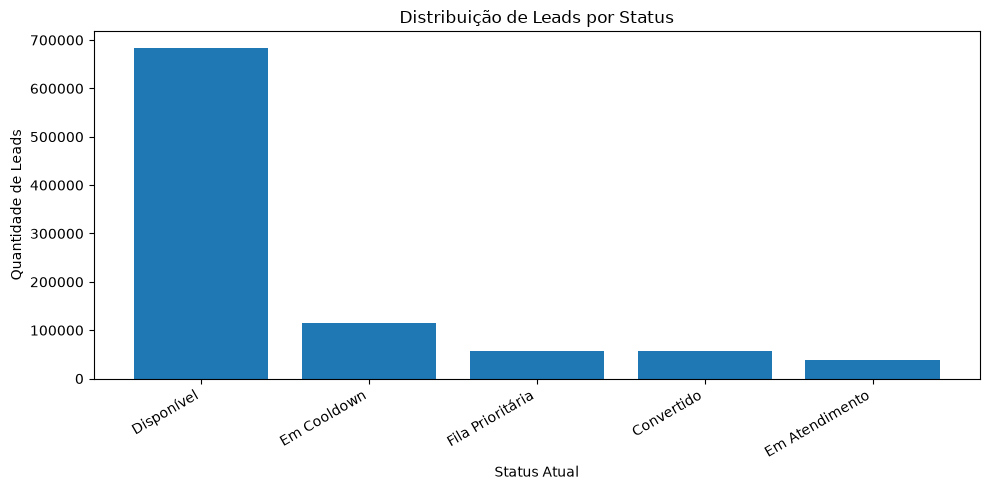

In [12]:
#Gráfico de status

grafico_barras_contagem(
    dados=dados_leads,
    coluna="status_atual",
    titulo="Distribuição de Leads por Status",
    nome_eixo_x="Status Atual",
    nome_eixo_y="Quantidade de Leads",
    caminho_saida=CAMINHO_GRAFICOS / "distribuicao_status.png"
)

## Leitura inicial

A distribuição por status permite entender o volume de leads disponíveis, bloqueados por cooldown, convertidos ou em fila prioritária.

Essa leitura é importante porque a proposta do projeto é justamente evitar que todos os leads retornem para uma fila genérica sem controle.

In [13]:
#Análise agricola-distribuição por cultura

distribuicao_cultura = (
    dados_leads
    .groupby("cultura")
    .agg(
        quantidade=("id_cliente", "count"),
        score_medio=("score_prioridade", "mean")
    )
    .reset_index()
    .sort_values(by="quantidade", ascending=False)
)

distribuicao_cultura["percentual"] = (
    distribuicao_cultura["quantidade"]
    / distribuicao_cultura["quantidade"].sum()
    * 100
)

distribuicao_cultura.round(2)

,cultura,quantidade,score_medio,percentual
0,Cana,428265,54.46,45.08
2,Soja,331745,49.36,34.92
1,Milho,189990,46.97,20.00


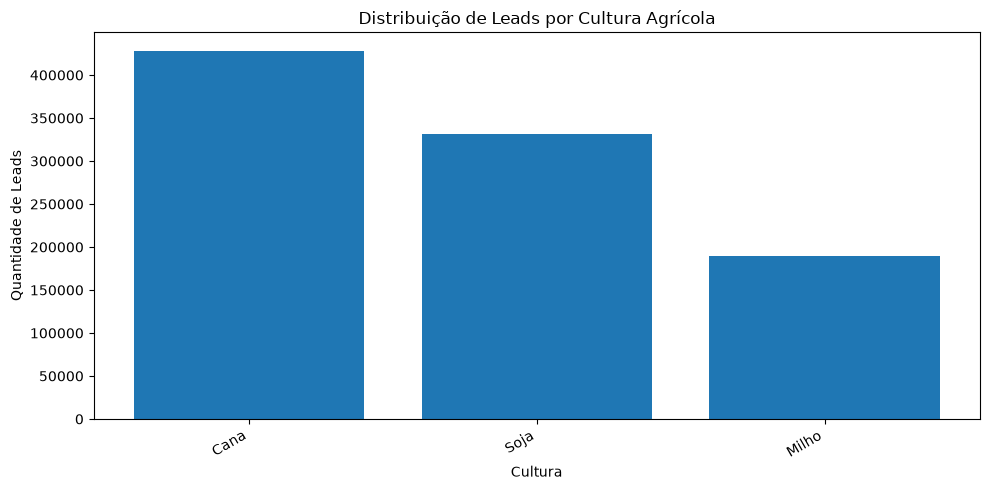

In [14]:
#Gráfico por cultura

grafico_barras_contagem(
    dados=dados_leads,
    coluna="cultura",
    titulo="Distribuição de Leads por Cultura Agrícola",
    nome_eixo_x="Cultura",
    nome_eixo_y="Quantidade de Leads",
    caminho_saida=CAMINHO_GRAFICOS / "distribuicao_cultura.png"
)

In [15]:
#Distribuição por estágio agricola

distribuicao_estagio = (
    dados_leads
    .groupby("estagio_atual")
    .agg(
        quantidade=("id_cliente", "count"),
        score_medio=("score_prioridade", "mean")
    )
    .reset_index()
    .sort_values(by="quantidade", ascending=False)
)

distribuicao_estagio["percentual"] = (
    distribuicao_estagio["quantidade"]
    / distribuicao_estagio["quantidade"].sum()
    * 100
)

distribuicao_estagio.round(2)

,estagio_atual,quantidade,score_medio,percentual
0,Desenvolvimento,284857,44.42,29.98
3,Safra,237541,59.89,25.00
2,Plantio,237277,66.69,24.98
1,Entresafra,190325,31.09,20.03


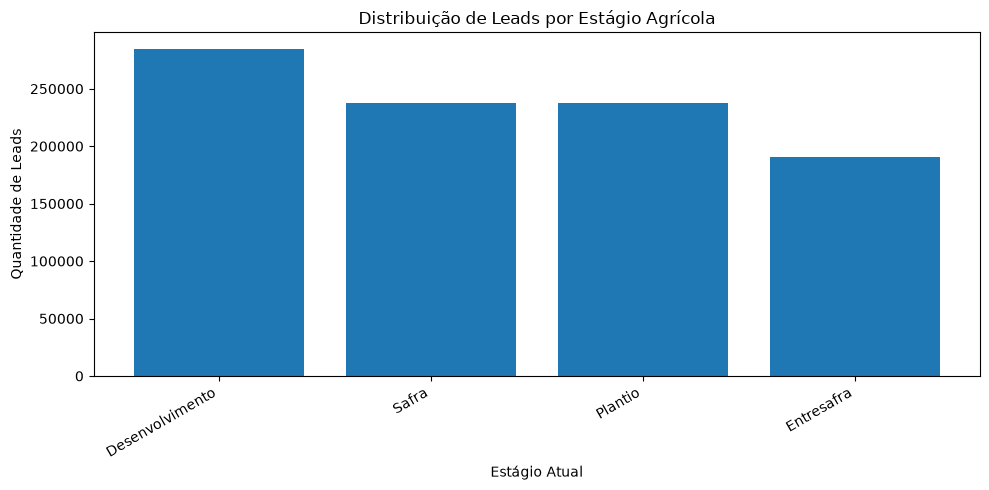

In [17]:
#Gráfico por estágio

grafico_barras_contagem(
    dados=dados_leads,
    coluna="estagio_atual",
    titulo="Distribuição de Leads por Estágio Agrícola",
    nome_eixo_x="Estágio Atual",
    nome_eixo_y="Quantidade de Leads",
    caminho_saida=CAMINHO_GRAFICOS / "distribuicao_estagio.png"
)

In [18]:
#Matriz cultura X estágio

matriz_cultura_estagio = pd.crosstab(
    dados_leads["cultura"],
    dados_leads["estagio_atual"]
)

matriz_cultura_estagio

estagio_atual,Desenvolvimento,Entresafra,Plantio,Safra
cultura,,,,
Cana,128022,85903,107413,106927
Milho,57127,38045,47063,47755
Soja,99708,66377,82801,82859


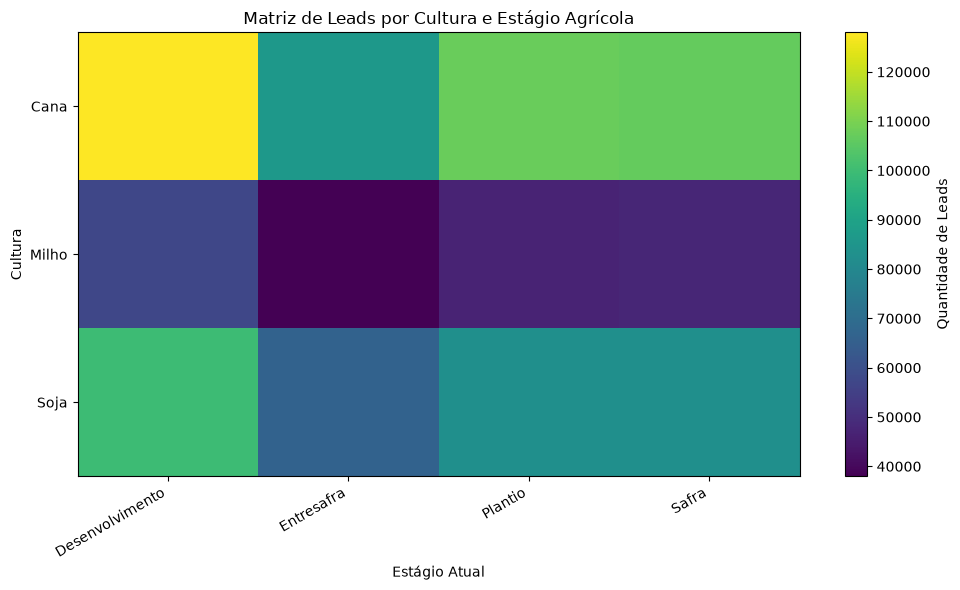

In [19]:
#Gráfico matriz cultura X estágio

grafico_matriz_cultura_estagio(
    matriz=matriz_cultura_estagio,
    titulo="Matriz de Leads por Cultura e Estágio Agrícola",
    caminho_saida=CAMINHO_GRAFICOS / "matriz_cultura_estagio.png"
)

In [20]:
#Análise de score / Estatística gerais do score

dados_leads["score_prioridade"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
).round(2)

count    950000.00
mean         51.18
std          34.64
min           0.00
25%          24.96
50%          49.52
75%          72.74
90%          94.53
95%         109.08
max         250.00
Name: score_prioridade, dtype: float64

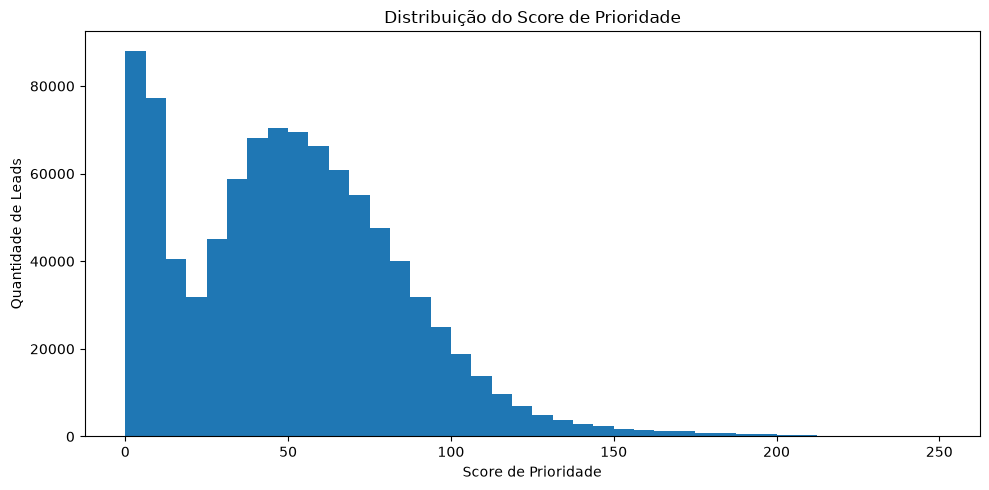

In [21]:
#Histograma do score

grafico_histograma_score(
    dados=dados_leads,
    coluna_score="score_prioridade",
    titulo="Distribuição do Score de Prioridade",
    caminho_saida=CAMINHO_GRAFICOS / "histograma_score_prioridade.png"
)

In [22]:
#Score médio por cultura

score_medio_cultura = (
    dados_leads
    .groupby("cultura")
    .agg(
        quantidade=("id_cliente", "count"),
        score_medio=("score_prioridade", "mean"),
        score_mediano=("score_prioridade", "median"),
        desvio_padrao=("score_prioridade", "std")
    )
    .reset_index()
    .sort_values(by="score_medio", ascending=False)
)

score_medio_cultura.round(2)

,cultura,quantidade,score_medio,score_mediano,desvio_padrao
0,Cana,428265,54.46,52.86,36.64
2,Soja,331745,49.36,47.88,33.22
1,Milho,189990,46.97,45.65,31.61


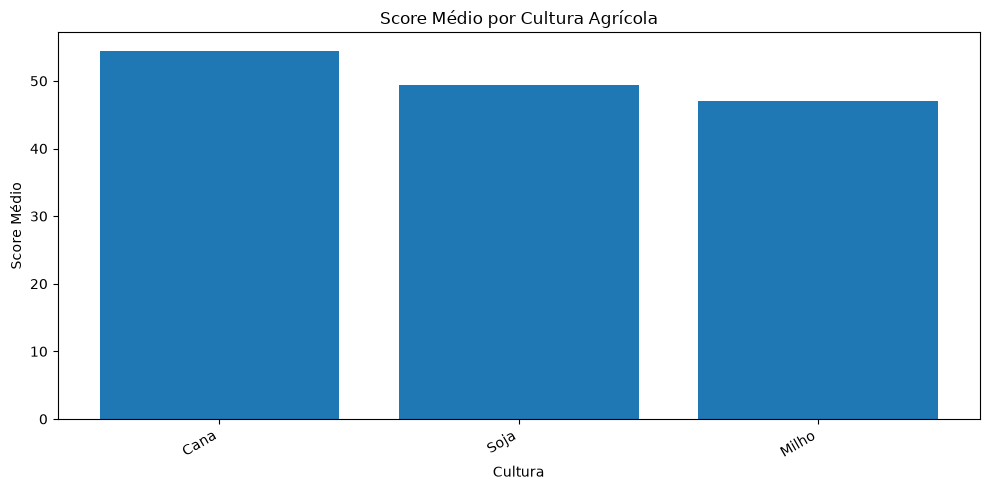

In [24]:
#Gráfico score médio por cultura

grafico_barras_agregado(
    dados=dados_leads,
    coluna_categoria="cultura",
    coluna_valor="score_prioridade",
    titulo="Score Médio por Cultura Agrícola",
    nome_eixo_x="Cultura",
    nome_eixo_y="Score Médio",
    caminho_saida=CAMINHO_GRAFICOS / "score_medio_cultura.png"
)

In [25]:
#Score médio por estágio agrícola

score_medio_estagio = (
    dados_leads
    .groupby("estagio_atual")
    .agg(
        quantidade=("id_cliente", "count"),
        score_medio=("score_prioridade", "mean"),
        score_mediano=("score_prioridade", "median"),
        desvio_padrao=("score_prioridade", "std")
    )
    .reset_index()
    .sort_values(by="score_medio", ascending=False)
)

score_medio_estagio.round(2)

,estagio_atual,quantidade,score_medio,score_mediano,desvio_padrao
2,Plantio,237277,66.69,70.48,40.34
3,Safra,237541,59.89,63.39,36.35
0,Desenvolvimento,284857,44.42,46.97,26.97
1,Entresafra,190325,31.09,32.88,18.87


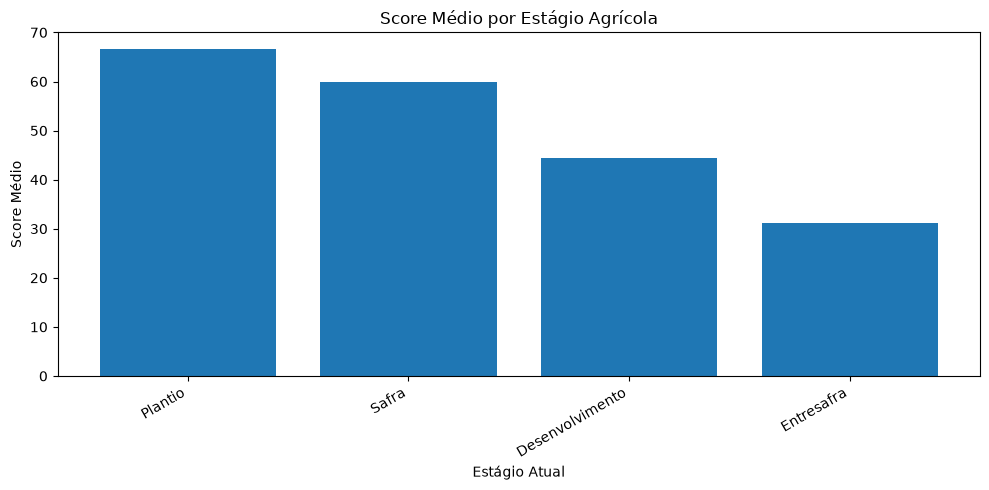

In [26]:
#Gráfico score médio por estágio

grafico_barras_agregado(
    dados=dados_leads,
    coluna_categoria="estagio_atual",
    coluna_valor="score_prioridade",
    titulo="Score Médio por Estágio Agrícola",
    nome_eixo_x="Estágio Atual",
    nome_eixo_y="Score Médio",
    caminho_saida=CAMINHO_GRAFICOS / "score_medio_estagio.png"
)

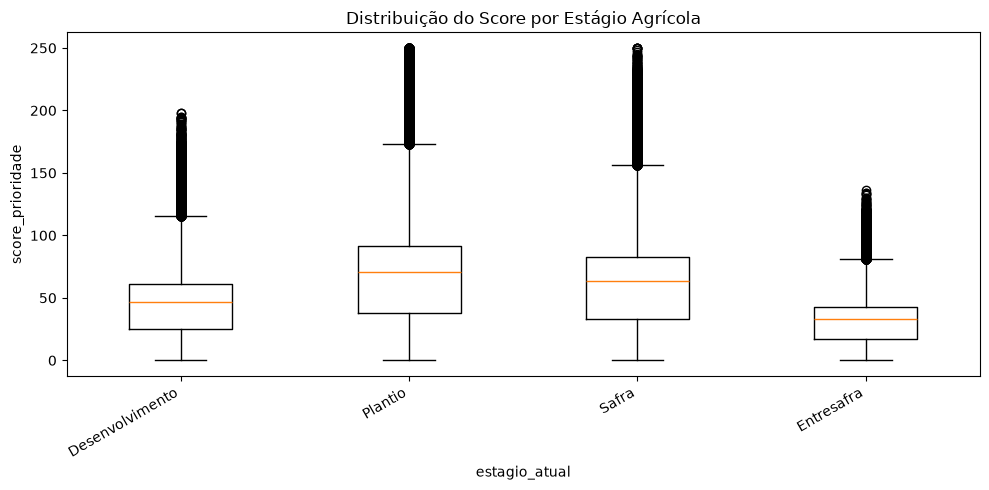

In [27]:
#Boxplot score por estágio

grafico_boxplot_score_por_categoria(
    dados=dados_leads,
    coluna_categoria="estagio_atual",
    coluna_score="score_prioridade",
    titulo="Distribuição do Score por Estágio Agrícola",
    caminho_saida=CAMINHO_GRAFICOS / "boxplot_score_estagio.png"
)

In [28]:
#Análise de oportunidades comerciais / Leads em momento agrícola crítico

leads_momento_critico = dados_leads[
    dados_leads["lead_em_momento_agricola_critico"]
].copy()

print(f"Total de leads em Plantio ou Safra: {len(leads_momento_critico):,}")
print(
    f"Percentual da base: "
    f"{len(leads_momento_critico) / len(dados_leads) * 100:.2f}%"
)

Total de leads em Plantio ou Safra: 474,818
Percentual da base: 49.98%


In [29]:
#Leads disponíveis em momento crítico

leads_criticos_disponiveis = dados_leads[
    (dados_leads["lead_em_momento_agricola_critico"])
    & (dados_leads["lead_disponivel_para_contato"])
].copy()

leads_criticos_disponiveis = leads_criticos_disponiveis.sort_values(
    by="score_prioridade",
    ascending=False
)

print(f"Leads críticos disponíveis: {len(leads_criticos_disponiveis):,}")

leads_criticos_disponiveis.head(20)

Leads críticos disponíveis: 341,855


,id_cliente,nome,telefone,cultura,estagio_atual,status_atual,ultimo_contato,cooldown_ate,score_prioridade,faixa_score,lead_em_momento_agricola_critico,lead_disponivel_para_contato,lead_engajado_whatsapp,lead_bloqueado
85792,85793,Marcos Santos,5518900085793,Cana,Plantio,Disponível,2026-06-04 17:08:57,NaT,165.0,Prioridade Máxima,True,True,False,False
835792,835793,Henrique Lima,5564900835793,Cana,Plantio,Disponível,2026-06-23 18:49:09,NaT,165.0,Prioridade Máxima,True,True,False,False
11675,11676,Mateus Souza,5514900011676,Cana,Plantio,Disponível,2026-05-31 20:07:57,NaT,165.0,Prioridade Máxima,True,True,False,False
794574,794575,João Fernandes,5514900794575,Cana,Plantio,Disponível,2026-06-06 23:18:07,NaT,165.0,Prioridade Máxima,True,True,False,False
886516,886517,Carlos Barbosa,5517900886517,Cana,Plantio,Disponível,2026-06-05 07:07:09,NaT,165.0,Prioridade Máxima,True,True,False,False
260362,260363,José Rodrigues,5512900260363,Cana,Plantio,Disponível,2026-06-23 03:11:00,NaT,165.0,Prioridade Máxima,True,True,False,False
350300,350301,José Silva,5516900350301,Cana,Plantio,Disponível,NaT,NaT,165.0,Prioridade Máxima,True,True,False,False
121581,121582,Paulo Silva,5544900121582,Cana,Plantio,Disponível,2026-06-08 02:33:58,NaT,165.0,Prioridade Máxima,True,True,False,False
237712,237713,Rafael Fernandes,5544900237713,Cana,Plantio,Disponível,2026-06-02 09:46:00,NaT,165.0,Prioridade Máxima,True,True,False,False
147143,147144,Rafael Santos,5515900147144,Cana,Plantio,Disponível,2026-06-22 10:33:58,NaT,165.0,Prioridade Máxima,True,True,False,False


In [30]:
#Leads engajados via WhatsApp

leads_engajados_whatsapp = dados_leads[
    dados_leads["lead_engajado_whatsapp"]
].copy()

leads_engajados_whatsapp = leads_engajados_whatsapp.sort_values(
    by="score_prioridade",
    ascending=False
)

print(f"Leads em fila prioritária por engajamento: {len(leads_engajados_whatsapp):,}")

leads_engajados_whatsapp.head(20)

Leads em fila prioritária por engajamento: 57,024


,id_cliente,nome,telefone,cultura,estagio_atual,status_atual,ultimo_contato,cooldown_ate,score_prioridade,faixa_score,lead_em_momento_agricola_critico,lead_disponivel_para_contato,lead_engajado_whatsapp,lead_bloqueado
301745,301746,Mateus Moura,5516900301746,Cana,Plantio,Fila Prioritária,2026-06-21 17:57:01,NaT,250.0,Prioridade Máxima,True,False,True,False
386565,386566,José Almeida,5544900386566,Cana,Plantio,Fila Prioritária,NaT,NaT,250.0,Prioridade Máxima,True,False,True,False
256475,256476,Ricardo Lima,5567900256476,Cana,Plantio,Fila Prioritária,2026-06-27 10:10:00,NaT,250.0,Prioridade Máxima,True,False,True,False
9335,9336,Carlos Ribeiro,5513900009336,Cana,Plantio,Fila Prioritária,NaT,NaT,250.0,Prioridade Máxima,True,False,True,False
406031,406032,José Moura,5544900406032,Cana,Plantio,Fila Prioritária,2026-06-18 11:59:03,NaT,250.0,Prioridade Máxima,True,False,True,False
816251,816252,Carlos Santos,5519900816252,Cana,Plantio,Fila Prioritária,2026-06-18 00:36:09,NaT,250.0,Prioridade Máxima,True,False,True,False
816603,816604,Marcelo Carvalho,5519900816604,Cana,Plantio,Fila Prioritária,2026-06-13 15:33:09,NaT,250.0,Prioridade Máxima,True,False,True,False
816041,816042,Paulo Nascimento,5512900816042,Cana,Plantio,Fila Prioritária,2026-06-09 23:20:09,NaT,250.0,Prioridade Máxima,True,False,True,False
811614,811615,Luiz Santos,5565900811615,Cana,Plantio,Fila Prioritária,2026-06-19 08:32:09,NaT,250.0,Prioridade Máxima,True,False,True,False
40625,40626,Daniel Araújo,5565900040626,Cana,Plantio,Fila Prioritária,2026-06-19 21:28:57,NaT,250.0,Prioridade Máxima,True,False,True,False


In [31]:
#Tabela de oportunidade comercial

resumo_oportunidade = pd.DataFrame({
    "categoria": [
        "Leads totais",
        "Leads em Plantio ou Safra",
        "Leads disponíveis em Plantio ou Safra",
        "Leads engajados via WhatsApp",
        "Leads bloqueados"
    ],
    "quantidade": [
        len(dados_leads),
        len(leads_momento_critico),
        len(leads_criticos_disponiveis),
        len(leads_engajados_whatsapp),
        dados_leads["lead_bloqueado"].sum()
    ]
})

resumo_oportunidade["percentual"] = (
    resumo_oportunidade["quantidade"]
    / len(dados_leads)
    * 100
)

resumo_oportunidade.round(2)

,categoria,quantidade,percentual
0,Leads totais,950000,100.00
1,Leads em Plantio ou Safra,474818,49.98
2,Leads disponíveis em Plantio ou Safra,341855,35.98
3,Leads engajados via WhatsApp,57024,6.00
4,Leads bloqueados,170960,18.00


In [32]:
#Ranking de prioridade

top_leads_prioritarios = (
    dados_leads[
        dados_leads["status_atual"].isin(["Disponível", "Fila Prioritária"])
    ]
    .sort_values(by="score_prioridade", ascending=False)
    .head(30)
)

top_leads_prioritarios[[
    "id_cliente",
    "nome",
    "telefone",
    "cultura",
    "estagio_atual",
    "status_atual",
    "score_prioridade",
    "faixa_score"
]]

,id_cliente,nome,telefone,cultura,estagio_atual,status_atual,score_prioridade,faixa_score
520068,520069,André Fernandes,5519900520069,Soja,Plantio,Fila Prioritária,250.0,Prioridade Máxima
629448,629449,Lucas Martins,5567900629449,Cana,Safra,Fila Prioritária,250.0,Prioridade Máxima
819429,819430,João Moura,5515900819430,Cana,Plantio,Fila Prioritária,250.0,Prioridade Máxima
816603,816604,Marcelo Carvalho,5519900816604,Cana,Plantio,Fila Prioritária,250.0,Prioridade Máxima
175030,175031,Paulo Almeida,5535900175031,Cana,Plantio,Fila Prioritária,250.0,Prioridade Máxima
406031,406032,José Moura,5544900406032,Cana,Plantio,Fila Prioritária,250.0,Prioridade Máxima
735548,735549,Rafael Santos,5519900735549,Cana,Plantio,Fila Prioritária,250.0,Prioridade Máxima
9335,9336,Carlos Ribeiro,5513900009336,Cana,Plantio,Fila Prioritária,250.0,Prioridade Máxima
665961,665962,Igor Moura,5566900665962,Cana,Plantio,Fila Prioritária,250.0,Prioridade Máxima
694850,694851,André Fernandes,5567900694851,Cana,Plantio,Fila Prioritária,250.0,Prioridade Máxima


In [33]:
#Salvar top leads prioritários

CAMINHO_TOP_LEADS = CAMINHO_OUTPUTS / "top_leads_prioritarios.csv"

top_leads_prioritarios.to_csv(
    CAMINHO_TOP_LEADS,
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo salvo em:", CAMINHO_TOP_LEADS)

Arquivo salvo em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\top_leads_prioritarios.csv


In [34]:
#Resumo executivo / Indicadores finais da EDA

indicadores_eda = {
    "total_leads": len(dados_leads),
    "score_medio_geral": round(dados_leads["score_prioridade"].mean(), 2),
    "score_mediano_geral": round(dados_leads["score_prioridade"].median(), 2),
    "leads_momento_critico": len(leads_momento_critico),
    "leads_criticos_disponiveis": len(leads_criticos_disponiveis),
    "leads_engajados_whatsapp": len(leads_engajados_whatsapp),
    "leads_bloqueados": int(dados_leads["lead_bloqueado"].sum())
}

indicadores_eda

{'total_leads': 950000,
 'score_medio_geral': np.float64(51.18),
 'score_mediano_geral': np.float64(49.52),
 'leads_momento_critico': 474818,
 'leads_criticos_disponiveis': 341855,
 'leads_engajados_whatsapp': 57024,
 'leads_bloqueados': 170960}

#Conclusão da análise

## Conclusões da Análise Exploratória

A análise exploratória mostra que a base possui uma distribuição operacional compatível com um cenário real de vendas agrícolas.

Os principais pontos observados são:

- existem leads em diferentes estados da máquina de contato;
- parte relevante da base está em momentos agrícolas críticos, como Plantio e Safra;
- o score de prioridade diferencia clientes conforme estágio agrícola, cultura e status operacional;
- leads disponíveis em Plantio ou Safra representam oportunidades comerciais mais urgentes;
- leads em Fila Prioritária representam clientes que já demonstraram engajamento;
- a existência de leads em Cooldown e Convertidos reforça a necessidade de uma engine de orquestração para evitar contatos indevidos.

Esses resultados justificam a próxima etapa do projeto: a construção da State Machine de orquestração.

In [35]:
#Fechar conexão

conexao.close()

print("Conexão encerrada.")


Conexão encerrada.
